# Free OBS LUT Maker
This tool is hosted by Google, created by Steve Seguin, and it's free to use, modify, etc. I just ask that any derivation or distribution of this code, commericial or otherwise, gives credit and a link back to the github repo: https://github.com/steveseguin/color-grading

## STEP 1 - Welcome to the Python Coding Language
To get the code started, we are going to need to import the needed Python libraries: these empower us to do matrix manipulation, computer vision, and machine learning. Doing this on Google Colab is easy thankfully - just hit the PLAY/RUN button on the code block below.

In [ ]:
import cv2 #  computer vision
from google.colab.patches import cv2_imshow

import numpy as np # matrix math
from matplotlib import pyplot as plt # Plotting software to help us visualize some things

from sklearn.preprocessing import PolynomialFeatures  # making math equations
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score # solving math equations

import warnings
warnings.filterwarnings("ignore")  # hides some warnings 

## STEP 2 - Get a Reference Colour Chart; Load those colour values in Python
Now lets create our digital color reference chart; or really, an array of RGB color values. This all needs to be based on a physical color reference chart of color values you have. I made my own for free; you can, too, or you can order a professional one online.

For mine, I went to the local paint store and picked up free paper color samples to make my color chart. At a minimum, you will need WHITE, GREY, and BLACK samples. Adding other colors will help, but they are not needed. I picked 9 colors total.

<img src="https://raw.githubusercontent.com/steveseguin/color-grading/master/Image2.png" width="200"/>

If you pick up Behr-branded color samples, you can reference their online website for the RGB values of the colors. ie: https://www.behr.ca/consumer/colors/paint/color/MQ1-02  They may not be 100% accurate, but perhaps good enough.

You can order professional color reference samples also, such as from https://www.amazon.com/Datacolor-SCK200-SpyderCHECKR-24/dp/B00LPS46TW, which may get you better results. Buyer beware though -- not all may work well with this script.

## Configuration Settings
Set these configuration options before running the notebook:
- **mb**: Brightness adjustment (-20 to 20, default: 0)
- **apply_rolloff**: Apply shadow/highlight rolloff curves (default: True)
- **use_weighted_regression**: Use weighted least squares to prioritize neutral colors (default: False)

In [ ]:
## CONFIGURATION OPTIONS - Set these early
mb = 0   #  Brightness adjustment: -20 to 20 is a good range to try; 0 is default
apply_rolloff = True  # Apply shadow/highlight rolloff curves to preserve extremes
use_weighted_regression = False  # Use weighted least squares (prioritizes neutrals)

print("Configuration:")
print(f"  Brightness adjustment (mb): {mb}")
print(f"  Apply rolloff curves: {apply_rolloff}")
print(f"  Use weighted regression: {use_weighted_regression}")

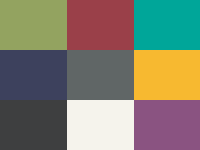

In [ ]:
total_rows = 3  # Change to the number of rows in your color chart. ie: 4
total_columns = 3 # Change to the number of columns in your color chart. ie: 6
cell_border_percentage = 25 # Adjust as needed; 0 to 50 are acceptable values.

# Update the follow values with your RGB values.
right = [[147,163,96],[154,64,73],[0,166,153],
		[61,65,93],[96,102,102],[247,185,48],
		[62,63,64],[245,243,236],[138,83,129]] ## [[RGB],[RGB],...[RGB]]  Modify with the RGB values of each color, in the order that you read a book

test = np.array(right).reshape((total_rows,total_columns,3)).astype("uint8") 
test = cv2.cvtColor(test, cv2.COLOR_RGB2BGR)
test = cv2.resize(test,(200,150),interpolation=cv2.INTER_NEAREST)
cv2_imshow(test) ## If the colors don't match, something is wrong. This is our color target for the output

wrong = np.zeros_like(right) 

## Step 3 - Take a photo of your colour chart, crop it, and upload it below
Below, let's take a photo of our our color reference chart taken with our camera under the lighting conditions we wish to create our OBS-LUT for and upload it to this script.

Image size doesn't matter a whole lot, but make sure the is cropped to fit the image.

Hit Cancel Upload if you want to use the default demo image instead.

Example Image to upload:

<img src="https://raw.githubusercontent.com/steveseguin/color-grading/master/Image1.png" width="200"/> or like this, for 6x4 pro cards <img src="https://raw.githubusercontent.com/steveseguin/color-grading/master/image.png" width="200"/>


--2023-03-01 18:30:46--  https://raw.githubusercontent.com/steveseguin/color-grading/master/logcrop.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23917 (23K) [image/jpeg]
Saving to: ‘logcrop.jpg’

logcrop.jpg         100%[===================>]  23.36K  --.-KB/s    in 0.002s  

2023-03-01 18:30:46 (14.5 MB/s) - ‘logcrop.jpg’ saved [23917/23917]



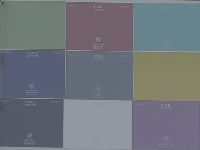

In [ ]:
from google.colab import files # lets us upload images to Google Colab from local storage
uploaded = files.upload()
img_file = None

for fn in uploaded.keys():  ## 
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
  img_file = fn

if (img_file==None): ## If no image is uploaded by user
  !wget https://raw.githubusercontent.com/steveseguin/color-grading/master/logcrop.jpg -O logcrop.jpg  # DOWNLOAD SAMPLE IMAGE
  img_file = "logcrop.jpg"
  img3 = cv2.imread(img_file, 1)
else:
  img3 = cv2.imread(img_file, 1)
  import os
  os.remove(img_file) ## CLEAN UP

w,h,_ = np.shape(img3) # GET SIZE OF IMAGE
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB) # CONVERT FROM BGR to RGB (OPENCV defaults to BGR for some reason?)

cv2_imshow(cv2.cvtColor(cv2.resize(img3,(200,150)), cv2.COLOR_RGB2BGR)) 

## You may need to re-run this code block a second time if you get an error the first time

## Step 4 - Let Python extract the colours from the image you uploaded
We are going to go thru all the colors in the image of the photographed color chart and get the peak RGB colors from it. 

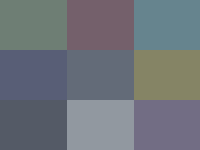

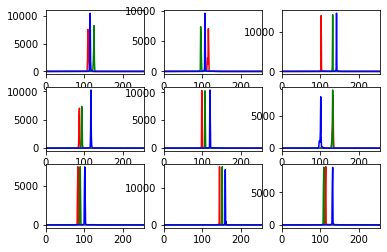

In [ ]:

color = ('r','g','b')
for x in range(total_rows):
	for y in range(total_columns):
		for i,col in enumerate(color):
			seg = img3[int(x*w/total_rows+((cell_border_percentage/200)*(w/total_rows))):int((x+1)*w/total_rows-((cell_border_percentage/200)*(w/total_rows))),int(y*h/total_columns+((cell_border_percentage/200)*(h/total_columns))):int((y+1)*h/total_columns-((cell_border_percentage/200)*(h/total_columns))),:] # We assume each color block is the same size and that the image is cropped correctly
			histr = cv2.calcHist([seg],[i],None,[256],[0,256]) # Create a histogram
			j = x*total_columns+y+1
			wrong[j-1][i]=np.where(np.max(histr)==histr)[0][0] # What is the PEAK color for each block? use this rather than the average RGB value.
			plt.subplot(total_rows,total_columns,j)
			plt.plot(histr,color = col) # Plot, so you can se what's going on.
			plt.xlim([0,256])
			
 # If successful, you should see some plots below. Each plot should have 1 blue, 1 red, and 1 green peak each. 
test = np.array(wrong).reshape((total_rows,total_columns,3)).astype("uint8") 
test = cv2.cvtColor(test, cv2.COLOR_RGB2BGR)
test = cv2.resize(test,(200,150),interpolation=cv2.INTER_NEAREST)
cv2_imshow(test)  ## THIS IS WHAT THE INPUT IT IS; confirm it matches the photo you uploaded.

## Step 5 - Teach Python how to convert from Bad colours to Good colours
This next step we are essentially trying to solve a mathematical optimization equation; it will give us our optimized colour-correcting transformation. RGB channels are each treated as independent functions.

The Basic Logic that we are doing is the following:

```y = a*x^2 + b*x + c ``` , a Polynomial Curve applied to Input Image as a color-transformation

```y1 = (y0 - y)```  , We want the input image to match the target image, or as close as possible.

*Note: By default, we are applying a 1st-degree polynomial; this is ideal for most applications as it avoids overfitting issues. If you have hundreds of reference colours, including very deep blacks and very bright whites, you might be able to get away with a 2nd-degree polynomial.*

In [ ]:
# Code: RGB channels are treated independently, using linear regression fitting

degreesA = 1  # <<====  Number of Polynomial degrees.  1 Recommended. 2 Max.

poly={}
colors = ["Red","Green","Blue"]
xp = np.linspace(0, 255, 255)
for rgb in range(3):
  www = np.ravel(wrong)[rgb::3]
  rrr = np.ravel(right)[rgb::3]
  
  if use_weighted_regression:
    # Calculate weights for weighted regression
    n = len(www)
    weights = np.ones(n)
    
    # Prioritize neutral colors (where R≈G≈B for all color samples)
    all_r = np.ravel(wrong)[0::3]
    all_g = np.ravel(wrong)[1::3]
    all_b = np.ravel(wrong)[2::3]
    
    for i in range(n):
      max_diff = max(abs(all_r[i] - all_g[i]), abs(all_g[i] - all_b[i]), abs(all_r[i] - all_b[i]))
      if max_diff < 20:  # Neutral colors
        weights[i] = 2.0  # Double weight for neutrals
    
    # Apply Huber weighting for outliers
    # First pass to get initial fit
    initial_poly = np.polyfit(www, rrr, degreesA)
    initial_p = np.poly1d(initial_poly)
    residuals = rrr - initial_p(www)
    
    # Huber weighting
    c = 1.345 * np.std(residuals)  # Huber's constant * std deviation
    for i in range(n):
      if abs(residuals[i]) > c:
        weights[i] *= c / abs(residuals[i])  # Reduce weight for outliers
    
    # Apply weighted polynomial fitting
    poly[rgb] = np.polyfit(www, rrr, degreesA, w=weights)
  else:
    poly[rgb] = np.polyfit(www, rrr, degreesA)
  
  p = np.poly1d(poly[rgb])
  
  delta = rrr - p(www)
  power = np.power(delta,2)
  mean = np.mean(power)
  final = np.sqrt(mean)
  print(colors[rgb],"error:",final)
  plt.subplot(3,1,rgb+1)
  _ = plt.plot(www, rrr, '.', xp, xp, '-', xp, p(xp), '--')
  plt.ylim(0,255)
  plt.show()
  if (final>30):
     print("\t ^ High number implies result is not that optimized")
  print()

You might notice that the results from the previous step provide information on required changes to contrast, brightness, and perhaps gamma. Adjusting your in-camera's contrast settings, based on those numbers, may reduce colour banding in later steps.

## Step 6 - Improve our results from Step 5 with Fancy Maths
This next code block is optional and I would recommend you do not run it if you are only using black, grey, and white as color references. It's best to run this step if you have a large varieties of reeference colours only.

This step tries to improve the previous step by converting those functions that were colour-channel-independent to colour-channel-dependent. That is, the value of the green and blue channels will have a small impact on what the red color will be, and etc.

The previous code block was a set of 1-D regressive linear functions. This code block tho is a set of 3-D (multivariate) regressive linear functions.

The math *kinda* looks like: R = R0*G0*B0*a, G = R0*G0*B0*b, B = R0*G0*B0*c

This step is more unstable than the previous one, but it can fix subtle hue shifts that might be present in skin-tones or such. 

Lastly, while you can tinker with the polynomial degree value of this code block as well, it is strongly advised that for most users to just leave it default. A higher value can lead to overfitting.

In [ ]:
degreesB=2  ## 2 or 3 only. 3 can lead to overfitting. 2 recommend for most users.

## Create more data points using previous step's function; this will help prevent overfitting with our next step.

grid = np.linspace(0,255, 2)
rainbow = np.zeros((len(grid)*len(grid)*len(grid),3))
counter = 0
for r in grid:
  for g in grid:
    for b in grid:
      rainbow[counter,0]=r
      rainbow[counter,1]=g
      rainbow[counter,2]=b
      counter+=1
      
wrong0 = np.vstack((wrong,rainbow))

for rgb in range(3):
  p = np.poly1d(poly[rgb])
  print(colors[rgb],"Pre-Process range:",int(np.min(rainbow[:,rgb])),"-",int(np.max(rainbow[:,rgb])))
  rainbow[:,rgb] = p(rainbow[:,rgb])
  print(colors[rgb],"Post-Process range:",int(np.min(rainbow[:,rgb])),"-",int(np.max(rainbow[:,rgb])))
  print()


right0 = np.vstack((right,rainbow))

r1 = np.ravel(wrong0)[0::3].astype(np.float32, copy=False)  # wrong
g1 = np.ravel(wrong0)[1::3].astype(np.float32, copy=False)
b1 = np.ravel(wrong0)[2::3].astype(np.float32, copy=False)

r0 = np.ravel(right0)[0::3].astype(np.float32, copy=False)  # right
g0 = np.ravel(right0)[1::3].astype(np.float32, copy=False)
b0 = np.ravel(right0)[2::3].astype(np.float32, copy=False)

rgb = np.array([r1,g1,b1])
coes = {}

## FIT THE DATA TO OUR MULTIVARIATE FUNCTIONS
def polyfit3d(rgb,pp,x0):  
    degrees = [(i, j, k) for i in range(pp) for j in range(pp) for k in range(pp)]  # list of monomials x**i * y**j to use
    matrix = np.stack([np.prod(rgb.T**d, axis=1) for d in degrees], axis=-1)   # stack monomials like columns
    
    if use_weighted_regression:
        # Calculate weights for weighted regression
        n = len(x0)
        weights = np.ones(n)
        
        # Prioritize neutral colors (where R≈G≈B)
        for i in range(n):
            r_val = rgb[0][i] if rgb.shape[0] > 0 else 0
            g_val = rgb[1][i] if rgb.shape[0] > 1 else 0
            b_val = rgb[2][i] if rgb.shape[0] > 2 else 0
            max_diff = max(abs(r_val - g_val), abs(g_val - b_val), abs(r_val - b_val))
            if max_diff < 20:  # Neutral colors
                weights[i] = 2.0  # Double weight for neutrals
        
        # Apply Huber weighting for outliers
        # First pass to get initial fit for residuals
        initial_coeff = np.linalg.lstsq(matrix, x0, rcond=None)[0]
        initial_fit = np.dot(matrix, initial_coeff)
        residuals = x0 - initial_fit
        
        # Huber weighting
        c = 1.345 * np.std(residuals)  # Huber's constant * std deviation
        for i in range(n):
            if abs(residuals[i]) > c:
                weights[i] *= c / abs(residuals[i])  # Reduce weight for outliers
        
        # Apply weighted least squares
        W = np.diag(weights)
        # Solve (X^T * W * X)^-1 * X^T * W * y
        XtWX = matrix.T @ W @ matrix
        XtWy = matrix.T @ W @ x0
        coeff = np.linalg.solve(XtWX, XtWy)
    else:
        coeff = np.linalg.lstsq(matrix, x0, rcond=None)[0]    # lstsq returns some additional info we ignore
    
    #print("Coefficients", coeff)    # in the same order as the monomials listed in "degrees"
    fit = np.dot(matrix, coeff)
    #print(np.sqrt(np.mean((x0-fit)**2)))  ## error
    return coeff
  
## PREDICT / SOLVE the function for our input data (getting our target data)
def poly3d(rgb,coeff,pp):  
    degrees = [(i, j, k) for i in range(pp) for j in range(pp) for k in range(pp)]  # list of monomials x**i * y**j to use
    matrix = np.stack([np.prod(rgb.T**d, axis=1) for d in degrees], axis=-1)   # stack monomials like columns
    fit = np.dot(matrix, coeff)
    return fit

## Generate and Save the functions; one function for each color type
coes[0] = polyfit3d(rgb,degreesB,r0) 
coes[1] = polyfit3d(rgb,degreesB,g0)
coes[2] = polyfit3d(rgb,degreesB,b0)


## PLOT DATA POINTS FOR ANALYSIS

rgb0 = np.array([poly3d(rgb,coes[0],degreesB),poly3d(rgb,coes[1],degreesB), poly3d(rgb,coes[2],degreesB)])

from mpl_toolkits.mplot3d import axes3d
import scipy as sp
import scipy.interpolate

fig = plt.figure(figsize=(12,6))
ax = axes3d.Axes3D(fig)

for i in range(len(rgb[0])):
    ax.plot(  [rgb[0,i],rgb0[0,i]],  [rgb[1,i],rgb0[1,i]],  [rgb[2,i],rgb0[2,i]],  'ro-')

ax.scatter3D(rgb0[0],rgb0[1],rgb0[2], c='g')
ax.scatter3D(rgb[0],rgb[1],rgb[2], c='b') 

# The graph reflects the transformation of each RGB colour value

## Step 8 - Upload an uncropped photo to test the results on!
We now want to upload an image that we want to colour-correct. This step is optional, but it will let us confirm how well things worked before creating our final OBS-LUT image.

Hit Cancel Upload to use the provided sample image.

Please note, the sample image should not be used if using your own color cards.

--2019-10-28 20:01:30--  https://raw.githubusercontent.com/steveseguin/color-grading/master/log.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.0.133, 151.101.64.133, 151.101.128.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.0.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1123880 (1.1M) [image/jpeg]
Saving to: ‘log.jpg’

log.jpg             100%[===================>]   1.07M  --.-KB/s    in 0.04s   

2019-10-28 20:01:31 (23.8 MB/s) - ‘log.jpg’ saved [1123880/1123880]



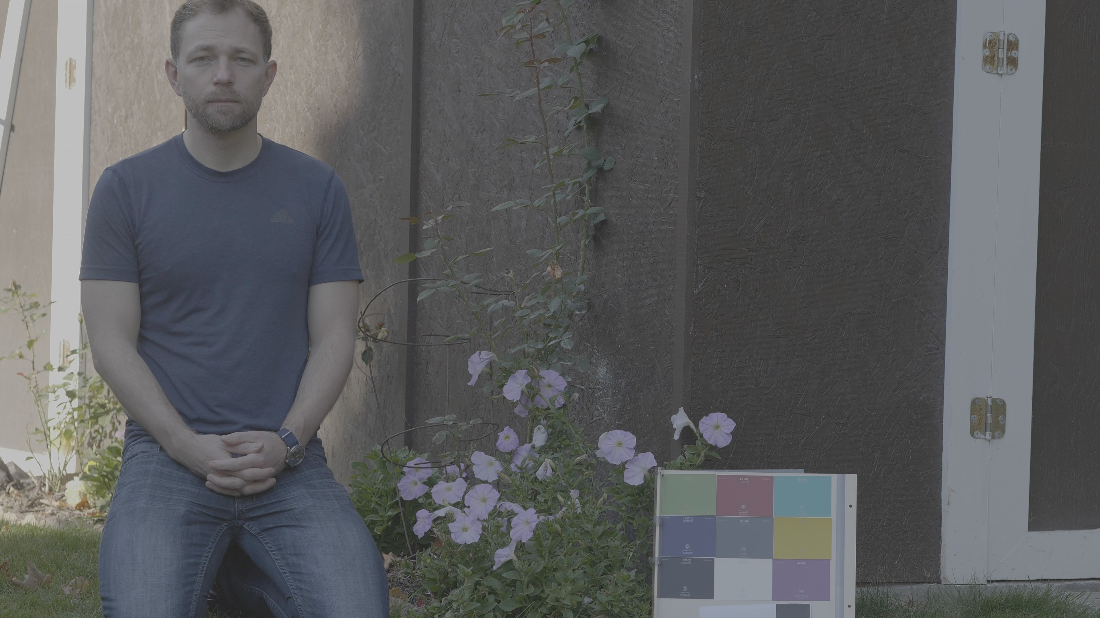

Dynamic range: 14 - 219


In [ ]:
from google.colab import files # lets us upload images to Google Colab from local storage
uploaded = files.upload()

img_file = None

for fn in uploaded.keys():  ## 
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
  print(uploaded.keys())
  img_file = fn
  
if (img_file==None): ## If no image is uploaded by user
  !wget https://raw.githubusercontent.com/steveseguin/color-grading/master/log.jpg -O log.jpg  # DOWNLOAD SAMPLE IMAGE
  img_file = "log.jpg"
  img2 = cv2.imread(img_file, 1)
else:
  img2 = cv2.imread(img_file, 1)
  import os
  os.remove(img_file)
  
ar = img2.shape[1]/img2.shape[0]
cv2_imshow(cv2.resize(img2,(1100,int(1100/ar))))
print("Dynamic range:",np.min(img2),"-",np.max(img2))

img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img2 = img2.astype(np.float32, copy=False)

# YOU MAY NEED TO RUN THIS TWICE FOR IT TO WORK

## Step 9 - Check out the result and make tweaks as needed
We will now apply the functional transforms on the image you just uploaded, to see how the results look. 

**If the image is too dark or too bright, you can adjust the brightness level by changing the "mb" value to either +20 or -20 and then re-run this step.** Feel free to fine-tune the brightness to your liking.

We will apply a small amount of gamma in a later step, to help perserve some shadow/highlight detail.

In [ ]:
def applyLUT(image):
  assert(image.dtype == "float32")
  for rgb in range(3):
    p = np.poly1d(poly[rgb])
    print("PRE range:",np.min(image[:,:,rgb]),"-",np.max(image[:,:,rgb]))
    image[:,:,rgb] = p(image[:,:,rgb])
    print("POST range:",np.min(image[:,:,rgb]),"-",np.max(image[:,:,rgb]))
    print()
  return image

def applyLUT2(image,pp):
  sss = np.shape(image[:,:,0])
  rgb = image.reshape(-1,3).T
  print(np.shape(rgb))
  Zr = poly3d(rgb,coes[0],pp).reshape(sss)
  Zg = poly3d(rgb,coes[1],pp).reshape(sss)
  Zb = poly3d(rgb,coes[2],pp).reshape(sss)
  image[:,:,0] = Zr
  image[:,:,1] = Zg
  image[:,:,2] = Zb
  return image
  

img = np.zeros_like(img2)
img[:] = img2[:]

print(np.min(img),np.max(img))

#img = applyLUT(img) + mb  ## You can disable applyLUT2 and enable this function instead if you are having problems
img = applyLUT2(img, degreesB) + mb


print(np.min(img),np.max(img))
if ((np.min(img)>25) & (np.max(img)<230)):
  print("Consider shooting in LOG or reducing contrast on your camera when recording")
elif (np.min(img)>25):
  print("Consider capturing with reduced exposure to capture more shadow detail")
elif (np.max(img)<230):
  print("Consider capturing with increase exposure to capture more highlight detail")
elif ((np.min(img)<-300) or (np.max(img)>500)):
  print("Consider shooting with more contrast or less dynamic range to get less colour banding")

test = np.zeros_like(img)
test[:] = img
test[np.where(test>255)]=255 # cut out bad highlights
test[np.where(test<0)]=0 # cut out bad shadows
test = test.astype(np.uint8, copy=False)
ar = test.shape[1]/test.shape[0]
cv2_imshow(cv2.cvtColor(cv2.resize(test,(1100,int(1100/ar))), cv2.COLOR_RGB2BGR))

## Step 9 - Setup a Gamma curve to perserve shadow and highlight details.

We will want to add a gentle roll-off at the black/white extremes when color correction is complete; this lets us to keep details in some highlights and shadows. When RGB > 225 or RGB < 30, we will refer to these Look-Up Tables to see how to best increase the dynamic range.

To see the Gamme Curve applied, see here
https://www.desmos.com/calculator/85cadg5cfx

In [ ]:
# Generate rolloff curves properly - iterate over input values, not output values
import numpy as np

# Keep the original array sizes for compatibility
LUT2 = np.zeros((492))  # Keep original size
LUT1 = np.zeros((492))  # Keep original size

# For highlight rolloff (values 225 and above)
for i in range(267):  # For inputs 225-491
    input_val = i + 225
    if input_val <= 255:
        # Apply smooth rolloff for 225-255 range
        t = (input_val - 225) / 30.0  # Normalize to 0-1
        # Square root curve for gentle highlight rolloff
        output_val = 225 + 30 * (t ** 0.5)
    else:
        # Values above 255 clamp to 255
        output_val = 255
    
    if i < 492:  # Safety check
        LUT2[i] = int(round(output_val))

# For values above 267, just set to 255 (shouldn't be used but for safety)
for i in range(267, 492):
    LUT2[i] = 255

# For shadow rolloff (values 30 and below)
for i in range(492):
    input_val = i - 461  # Maps to -461 to 30
    if input_val < 0:
        # Negative values clamp to 0
        output_val = 0
    elif input_val <= 30:
        # Apply smooth rolloff for 0-30 range
        t = input_val / 30.0  # Normalize to 0-1
        # Square curve for gentle shadow rolloff
        output_val = 30 * (t ** 2)
    else:
        # Values above 30 pass through (shouldn't happen in practice)
        output_val = min(input_val, 255)
    
    LUT1[i] = int(round(output_val))

print(f"Generated rolloff curves:")
print(f"LUT2 shape: {LUT2.shape}, LUT1 shape: {LUT1.shape}")
print(f"LUT2[0] (input 225) = {LUT2[0]}")
print(f"LUT2[30] (input 255) = {LUT2[30]}")
print(f"LUT1[461] (input 0) = {LUT1[461]}")
print(f"LUT1[491] (input 30) = {LUT1[491]}")

## Step 10 - Applying the Gamma Curve to the Image

This just applies the gamma curve that we just created to the image. Fine details in the shadows that may have previously been lost will become visible now.

The step may not be desirable always, so if you do choose to skip it, also remember to disable it in the final LUT PNG generation step.

In [ ]:
imgg = np.zeros_like(img)
imgg[:] = img[:]

print("Pre-Rolloff Curve Dynamic range:",np.min(imgg),"->",np.max(imgg))

# Apply rolloff curves only if enabled
if apply_rolloff:
  print("Applying shadow/highlight rolloff curves...")
  where = np.where((imgg>225) &(imgg<492))
  out = LUT2[np.uint16(np.round(imgg[where]-225))].astype(np.float32, copy=False)
  imgg[where] = out
  where = np.where((imgg<=30) & (imgg>-461))
  out = LUT1[np.uint16(np.round(imgg[where]+461))].astype(np.float32, copy=False)
  imgg[where] = out
  
  imgg[np.where(imgg>=492)]=255
  imgg[np.where(imgg<=-461)]=0
  print("Post-Rolloff Curve Dynamic range:",np.min(imgg),"->",np.max(imgg))
else:
  print("Rolloff curves disabled - clamping values only")

imgg[np.where(imgg>254)]=255 # cut out bad highlights
imgg[np.where(imgg<1)]=0 # cut out bad shadows
imgg = imgg.astype(np.uint8, copy=False)
avglum = np.mean(np.sqrt( 0.299*imgg[:,:,0]**2 + 0.587*imgg[:,:,1]**2 + 0.114*imgg[:,:,2]**2 ))
print("Final Dynamic range:",np.min(imgg),"-",np.max(imgg), ", Average Lumin Value:",avglum)
ar = imgg.shape[1]/imgg.shape[0]
cv2_imshow(cv2.cvtColor(cv2.resize(imgg,(1100,int(1100/ar))), cv2.COLOR_RGB2BGR))

## Step 11 - Generating out PNG LUT file for OBS
And Finally, using what we tried out above, we can generate our OBS LUT as a PNG file. This will apply the colour transformation, brightness changes if any were made, and apply the gentle-Gamma curve. Feel free to make changes to the code as desired to vary the outcome.

Once the LUT PNG file is generated, just right click the LUT Image, click "Save Image As..", and download it for use in OBS or elsewhere.

In [ ]:
## We are going to download a "neutral" PNG LUT and modify it. You can use your own LUTs instead if you want to modify the code a bit
!wget https://raw.githubusercontent.com/steveseguin/color-grading/master/neutral-lut.png -O neutral-lut.png  # DOWNLOAD LUT FROM GITHUB
img_file = "neutral-lut.png"

# LOAD INTO PYTHON
lutimg = cv2.imread(img_file, 1) 
lutimg = cv2.cvtColor(lutimg, cv2.COLOR_BGR2RGB)

## ANALYTICS
avglum = np.mean(np.sqrt( 0.299*lutimg[:,:,0]**2 + 0.587*lutimg[:,:,1]**2 + 0.114*lutimg[:,:,2]**2 ))  # via: https://stackoverflow.com/questions/596216/formula-to-determine-brightness-of-rgb-color
print("PRE PROCESSING - Dynamic range:",np.min(lutimg),"-",np.max(lutimg), ", Average Lumin Value:",avglum)

lutimg = lutimg.astype(np.float32, copy=False)

## If we want to increase the brightness
## We will use what was set earlier if not defined below
# mb = 0 # default
if (mb!=0):
  print()
  print("\tfyi: Brightness is being adjusted from default; adding",str(mb),"more brightness")
  
print()
print(" R-> G-> B-> ")
print()

## APPLY THE COLOR CORRECTION
#lutimg = applyLUT(lutimg) + mb
lutimg = applyLUT2(lutimg,degreesB) + mb  ## Experimental alternative to applyLUT

## APPLY ROLLOFF CURVES ONLY IF ENABLED
if apply_rolloff:
  print("Applying rolloff curves to LUT...")
  ## APPLY HIGHLIGHT GAMMA CURVE
  where = np.where((lutimg>225) &(lutimg<492))
  out = LUT2[np.uint16(np.round(lutimg[where]-225))]
  lutimg[where] = out

  ## APPLY SHADOW GAMMA CURVE
  where = np.where((lutimg<=30) & (lutimg>-461))  
  out = LUT1[np.uint16(np.round(lutimg[where]+461))]
  lutimg[where] = out
else:
  print("Rolloff curves disabled - using simple clamping")

## CLEAN UP OUT-OF-BOUNDS DATA
lutimg[np.where(lutimg>255)]=255 # cut out bad highlights
lutimg[np.where(lutimg<0)]=0 # cut out bad shadows
lutimg = lutimg.astype(np.uint8, copy=False)

## ANALYTICS
avglum = np.mean(np.sqrt( 0.299*lutimg[:,:,0]**2 + 0.587*lutimg[:,:,1]**2 + 0.114*lutimg[:,:,2]**2 ))  # via: https://stackoverflow.com/questions/596216/formula-to-determine-brightness-of-rgb-color
print("POST-PROCESSING - Dynamic range:",np.min(lutimg),"-",np.max(lutimg), ", Average Lumin Value:",avglum)
print()
print("Done processing!")
print("--> RIGHT CLICK IMAGE AND SELECT 'SAVE IMAGE AS' TO SAVE; as .png filetype ideally <--")
## GENERATE THE FINAL LUT
cv2_imshow(cv2.cvtColor(lutimg,cv2.COLOR_RGB2BGR))







## SAMPLE OF GENERATING A 3D CUBE LUT, for those wanting something newer/better 

ls=64 # lut size ; 33 is also a common option

r=0
g=0
b=0
img = np.zeros((ls*ls*ls,3), np.float32)

for x in range(0,ls*ls*ls): # create a neutral LUT first
    if r>=ls:
        r=0
        g+=1
    if g>=ls:
        g=0
        b+=1
    img[x,0]=1/(ls-1)*r
    img[x,1]=1/(ls-1)*g
    img[x,2]=1/(ls-1)*b
    r+=1

img = img.reshape((-1,ls*ls,3))
lutimg = applyLUT2(img*255.0, degreesB) + mb # apply the basic color correction

## APPLY ROLLOFF CURVES TO CUBE LUT IF ENABLED
if apply_rolloff:
  ## APPLY HIGHLIGHT GAMMA CURVE; 8-bit crude, so needs improvement
  where = np.where((lutimg>225) &(lutimg<492))
  out = LUT2[np.uint16(np.round(lutimg[where]-225))]
  lutimg[where] = out

  ## APPLY SHADOW GAMMA CURVE; 8-bit crude, so needs improvement
  where = np.where((lutimg<=30) & (lutimg>-461))  
  out = LUT1[np.uint16(np.round(lutimg[where]+461))]
  lutimg[where] = out

# Always clamp regardless of rolloff setting
lutimg[np.where(lutimg>255)]=255
lutimg[np.where(lutimg<0)]=0

img = lutimg/255.0
img = img.reshape((-1,3))

with open('result.cube', 'w') as the_file: # save the CUBE LUT to this colab folder I guess
    the_file.write("LUT_3D_SIZE "+str(ls)+"\n")
    for x in range(ls*ls*ls):
        the_file.write("{:1.6f}".format(img[x,0])+" "+"{:1.6f}".format(img[x,1])+" "+"{:1.6f}".format(img[x,2])+'\n')

## Step 12 - Load the PNG file into OBS as a LUT Filter

You now have the LUT file and ready to be loaded into OBS. While you may need to generate a new LUT file every time your camera settings change or lighting changes, creating a new LUT is fairly easy once you have your colour reference chart made and on hand.

I find these LUTS particularly useful for live streaming and I find myself struggling to colour-correct things with OBS provided tools alone.

# TIPS FOR IMPROVING RESULTS

### Low contrast results...
Based on our sample test data, our results show that our OBS-LUT has a Dynamic range of 0 to 255. Since we were using a LOG profile as input, we generated a fairly dynamic LUT profile. If the source image is of high contrast and low dynamic range though, or perhaps its too dark or too bright, the resultant LUT may be of low dynamics with a range of 30 to 240. In such cases, it might be best to adjust in-camera settings to reduce contrast or change exposure to optimize things.

If not possible to change camera settings, we can also adjust this issue in OBS, perhaps by increasing contrast after the LUT is applied, but that may lead to increased color banding. Another option is to reduce the amount of LUT applied to just 80%; a blended mix of original and transformed content.

### Overly WARM/DARK/BLUE/GREEN/WHITE results..

When we import a LUT into OBS, we may find that the color is too warm or too cold or too dark. Reduce the "Amount" of LUT filtering applied to the image in OBS, perhaps to 80%, to get a good balance of original input and the LUT. This can also help with banding or highlight/shadow issues. 

Another option is to modify the "mb" variable, to increase or reduce brightness, before the LUT is generated. See the code above for more details there.

Try also putting the Color Reference board you have in different lighting; too bright or too dark and it may cause the image to become too bright or too dark. Ideally, it should be getting balanced lighting.

You may also need to double check that all your color-cards are correctly calibrated and measured. Sometimes reducing your colors to just white, grey, and black can help reduce color shifts. Sometimes adding many more colors can also help. Experiment.

<img src="https://raw.githubusercontent.com/steveseguin/color-grading/master/obs-layout.jpg" width="700"/>

### Don't use OBS?
If OBS is not something you use, and you would just like to apply such a LUT to a static video file you have, you can modify the above code to work with video files.

An additional benefit of this approach is that the LUT used would not not be bound by 0-255, but rather -250 to +450, so less data would be lost within the highlights and shadows. It can also be configured to work with 10-bit video files to retain even more data.

Please see my github repo for a downloadable version of these scripts that you can try to apply on videos. Beware though: the code for such a task is only partially complete at current. I wouldn't' recommend this however unless you are a Python programmer or are willing to cough up a lot of cash to get me to continue working on it for you.


Cheers!

-steve